In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
sns.set_theme(style="whitegrid", context="talk")

In [12]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

DATA_PATH = Path("../data/master/germany_ida_master_15min.parquet")
TARGET = "ida1_minus_da_spread_eur_mwh"
LOCAL_TZ = "Europe/Berlin"

df = pd.read_parquet(DATA_PATH)

df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)

if "timestamp_local" in df.columns:
    df["timestamp_local"] = pd.to_datetime(df["timestamp_local"], utc=True).dt.tz_convert(LOCAL_TZ)
else:
    df["timestamp_local"] = df["timestamp_utc"].dt.tz_convert(LOCAL_TZ)

df = df.sort_values("timestamp_utc").reset_index(drop=True)

print("Loaded rows:", len(df))
print("Loaded columns:", len(df.columns))
print("UTC coverage:", df["timestamp_utc"].min(), "->", df["timestamp_utc"].max())
print("Local coverage:", df["timestamp_local"].min(), "->", df["timestamp_local"].max())

Loaded rows: 92348
Loaded columns: 127
UTC coverage: 2020-12-31 23:00:00+00:00 -> 2026-06-08 21:45:00+00:00
Local coverage: 2021-01-01 00:00:00+01:00 -> 2026-05-15 23:45:00+02:00


In [13]:
def add_if_columns_exist(df, new_col, cols, signs=None):
    if signs is None:
        signs = [1] * len(cols)

    missing = [c for c in cols if c not in df.columns]
    if missing:
        print(f"Skipping {new_col}; missing columns: {missing}")
        return

    out = 0
    for c, s in zip(cols, signs):
        out = out + s * df[c]
    df[new_col] = out


# Calendar / segment labels
df["year"] = df["timestamp_local"].dt.year
df["month"] = df["timestamp_local"].dt.month
df["hour_local"] = df["timestamp_local"].dt.hour
df["quarter_hour_local"] = df["timestamp_local"].dt.minute // 15
df["weekday_local"] = df["timestamp_local"].dt.weekday
df["date_local"] = df["timestamp_local"].dt.date

df["sample_segment"] = np.where(df["year"].eq(2021), "2021", "2024_2026")


# Actual wind / renewable totals
add_if_columns_exist(
    df,
    "actual_wind_total_mw",
    [
        "actual_generation_wind_onshore_actual_aggregated",
        "actual_generation_wind_offshore_actual_aggregated",
    ],
)

add_if_columns_exist(
    df,
    "actual_renewable_wind_solar_mw",
    [
        "actual_generation_wind_onshore_actual_aggregated",
        "actual_generation_wind_offshore_actual_aggregated",
        "actual_generation_solar_actual_aggregated",
    ],
)


# Total actual generation from aggregated source columns
actual_generation_agg_cols = [
    c for c in df.columns
    if c.startswith("actual_generation_") and c.endswith("_actual_aggregated")
]

if actual_generation_agg_cols:
    df["actual_total_generation_aggregated_mw"] = df[actual_generation_agg_cols].sum(axis=1, min_count=1)
    print("Actual generation source columns used:", len(actual_generation_agg_cols))


# Forecast errors: actual - forecast
if "actual_generation_solar_actual_aggregated" in df.columns and "solar_forecast_da_mw" in df.columns:
    df["solar_forecast_error_actual_minus_da_mw"] = (
        df["actual_generation_solar_actual_aggregated"] - df["solar_forecast_da_mw"]
    )

if "actual_generation_solar_actual_aggregated" in df.columns and "solar_forecast_id_mw" in df.columns:
    df["solar_forecast_error_actual_minus_id_mw"] = (
        df["actual_generation_solar_actual_aggregated"] - df["solar_forecast_id_mw"]
    )

if "actual_wind_total_mw" in df.columns and "wind_total_forecast_da_mw" in df.columns:
    df["wind_total_forecast_error_actual_minus_da_mw"] = (
        df["actual_wind_total_mw"] - df["wind_total_forecast_da_mw"]
    )

if "actual_wind_total_mw" in df.columns and "wind_total_forecast_id_mw" in df.columns:
    df["wind_total_forecast_error_actual_minus_id_mw"] = (
        df["actual_wind_total_mw"] - df["wind_total_forecast_id_mw"]
    )

if "actual_renewable_wind_solar_mw" in df.columns and "renewable_total_forecast_da_mw" in df.columns:
    df["renewable_forecast_error_actual_minus_da_mw"] = (
        df["actual_renewable_wind_solar_mw"] - df["renewable_total_forecast_da_mw"]
    )

if "actual_renewable_wind_solar_mw" in df.columns and "renewable_total_forecast_id_mw" in df.columns:
    df["renewable_forecast_error_actual_minus_id_mw"] = (
        df["actual_renewable_wind_solar_mw"] - df["renewable_total_forecast_id_mw"]
    )


# Residual load features
if "load_forecast_da_mw" in df.columns and "renewable_total_forecast_da_mw" in df.columns:
    df["residual_load_forecast_da_mw"] = (
        df["load_forecast_da_mw"] - df["renewable_total_forecast_da_mw"]
    )

if "load_forecast_da_mw" in df.columns and "renewable_total_forecast_id_mw" in df.columns:
    # Approximation: ID renewable update, but DA load forecast.
    df["residual_load_forecast_id_approx_mw"] = (
        df["load_forecast_da_mw"] - df["renewable_total_forecast_id_mw"]
    )

if "actual_load_actual_load" in df.columns and "actual_renewable_wind_solar_mw" in df.columns:
    df["actual_residual_load_wind_solar_mw"] = (
        df["actual_load_actual_load"] - df["actual_renewable_wind_solar_mw"]
    )

if "actual_residual_load_wind_solar_mw" in df.columns and "residual_load_forecast_da_mw" in df.columns:
    df["residual_load_error_actual_minus_da_mw"] = (
        df["actual_residual_load_wind_solar_mw"] - df["residual_load_forecast_da_mw"]
    )

if "residual_load_forecast_id_approx_mw" in df.columns and "residual_load_forecast_da_mw" in df.columns:
    df["residual_load_revision_id_minus_da_approx_mw"] = (
        df["residual_load_forecast_id_approx_mw"] - df["residual_load_forecast_da_mw"]
    )

if "actual_total_generation_aggregated_mw" in df.columns and "total_generation_forecast_da_mw" in df.columns:
    df["total_generation_forecast_error_actual_minus_da_mw"] = (
        df["actual_total_generation_aggregated_mw"] - df["total_generation_forecast_da_mw"]
    )


# Price lags
for lag in [1, 2, 4, 8, 96]:
    if TARGET in df.columns:
        df[f"spread_lag_{lag}"] = df[TARGET].shift(lag)
    if "ida1_price_eur_mwh" in df.columns:
        df[f"ida1_price_lag_{lag}"] = df["ida1_price_eur_mwh"].shift(lag)
    if "da_price_eur_mwh" in df.columns:
        df[f"da_price_lag_{lag}"] = df["da_price_eur_mwh"].shift(lag)


if TARGET not in df.columns and "ida1_price_eur_mwh" in df.columns and "da_price_eur_mwh" in df.columns:
    df[TARGET] = df["ida1_price_eur_mwh"] - df["da_price_eur_mwh"]


print("Done feature engineering.")

Actual generation source columns used: 17
Done feature engineering.


In [14]:
def numeric_existing(data, cols):
    return [
        c for c in cols
        if c in data.columns and pd.api.types.is_numeric_dtype(data[c])
    ]


def plot_corr_bar(data, target, features, title, method="pearson", top_n=35, figsize=(11, 9)):
    cols = numeric_existing(data, [target] + features)

    if target not in cols:
        print(f"Target {target} missing or non-numeric.")
        return None

    corr = data[cols].corr(method=method)[target].drop(target).dropna()
    corr = corr.sort_values(key=lambda s: s.abs(), ascending=False).head(top_n)

    if corr.empty:
        print("No correlations to plot.")
        return corr

    fig_height = max(figsize[1], 0.32 * len(corr))
    plt.figure(figsize=(figsize[0], fig_height))

    y = np.arange(len(corr))
    colors = np.where(corr.values >= 0, "tab:red", "tab:blue")

    plt.barh(y, corr.values, color=colors, alpha=0.85)
    plt.yticks(y, corr.index)
    plt.axvline(0, color="black", linewidth=1)
    plt.xlabel(f"{method.capitalize()} correlation with {target}")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    return corr


def plot_corr_heatmap(data, cols, title, method="pearson", figsize=None):
    cols = numeric_existing(data, cols)

    if len(cols) < 2:
        print("Not enough numeric columns for heatmap.")
        return None

    corr = data[cols].corr(method=method)

    if figsize is None:
        figsize = (max(10, 0.55 * len(cols)), max(8, 0.50 * len(cols)))

    plt.figure(figsize=figsize)
    im = plt.imshow(corr.values, vmin=-1, vmax=1, cmap="coolwarm", aspect="auto")
    plt.colorbar(im, label=f"{method.capitalize()} correlation")

    plt.xticks(np.arange(len(cols)), cols, rotation=90)
    plt.yticks(np.arange(len(cols)), cols)
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return corr


def plot_scatter(data, x, y, title=None, alpha=0.25, figsize=(7, 5)):
    if x not in data.columns or y not in data.columns:
        print(f"Missing {x} or {y}")
        return

    d = data[[x, y]].dropna()

    plt.figure(figsize=figsize)
    plt.scatter(d[x], d[y], alpha=alpha, s=10)
    plt.axhline(0, color="black", linewidth=1)
    plt.axvline(0, color="black", linewidth=1)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title or f"{y} vs {x}")
    plt.tight_layout()
    plt.show()


def plot_binned_relationship(data, x, y, bins=30, title=None, figsize=(8, 5)):
    if x not in data.columns or y not in data.columns:
        print(f"Missing {x} or {y}")
        return

    d = data[[x, y]].dropna().copy()
    d["bin"] = pd.qcut(d[x], q=bins, duplicates="drop")

    binned = (
        d.groupby("bin", observed=True)
         .agg(
             x_mean=(x, "mean"),
             y_mean=(y, "mean"),
             y_std=(y, "std"),
             n=(y, "count"),
         )
         .reset_index(drop=True)
    )

    binned["sem"] = binned["y_std"] / np.sqrt(binned["n"])

    plt.figure(figsize=figsize)
    plt.plot(binned["x_mean"], binned["y_mean"], marker="o")
    plt.fill_between(
        binned["x_mean"],
        binned["y_mean"] - 1.96 * binned["sem"],
        binned["y_mean"] + 1.96 * binned["sem"],
        alpha=0.25,
    )
    plt.axhline(0, color="black", linewidth=1)
    plt.axvline(0, color="black", linewidth=1)
    plt.xlabel(x)
    plt.ylabel(f"Mean {y}")
    plt.title(title or f"Binned relationship: {y} vs {x}")
    plt.tight_layout()
    plt.show()

    return binned

In [15]:
analysis_df = df.dropna(subset=[TARGET]).copy()

print("Rows with target:", len(analysis_df))

forecast_revision_features = [
    "solar_forecast_revision_id_minus_da_mw",
    "wind_onshore_forecast_revision_id_minus_da_mw",
    "wind_offshore_forecast_revision_id_minus_da_mw",
    "wind_total_forecast_revision_id_minus_da_mw",
    "renewable_total_forecast_revision_id_minus_da_mw",
    "residual_load_revision_id_minus_da_approx_mw",
]

forecast_level_features = [
    "solar_forecast_da_mw",
    "wind_total_forecast_da_mw",
    "renewable_total_forecast_da_mw",
    "solar_forecast_id_mw",
    "wind_total_forecast_id_mw",
    "renewable_total_forecast_id_mw",
    "load_forecast_da_mw",
    "residual_load_forecast_da_mw",
    "residual_load_forecast_id_approx_mw",
    "total_generation_forecast_da_mw",
]

expost_error_features = [
    "solar_forecast_error_actual_minus_da_mw",
    "wind_total_forecast_error_actual_minus_da_mw",
    "renewable_forecast_error_actual_minus_da_mw",
    "solar_forecast_error_actual_minus_id_mw",
    "wind_total_forecast_error_actual_minus_id_mw",
    "renewable_forecast_error_actual_minus_id_mw",
    "residual_load_error_actual_minus_da_mw",
    "total_generation_forecast_error_actual_minus_da_mw",
]

actual_generation_features = [
    "actual_load_actual_load",
    "actual_residual_load_wind_solar_mw",
    "actual_total_generation_aggregated_mw",
    "actual_generation_solar_actual_aggregated",
    "actual_generation_wind_onshore_actual_aggregated",
    "actual_generation_wind_offshore_actual_aggregated",
    "actual_wind_total_mw",
    "actual_renewable_wind_solar_mw",
    "actual_generation_fossil_gas_actual_aggregated",
    "actual_generation_fossil_hard_coal_actual_aggregated",
    "actual_generation_fossil_brown_coal_lignite_actual_aggregated",
    "actual_generation_nuclear_actual_aggregated",
    "actual_generation_hydro_pumped_storage_actual_aggregated",
    "actual_generation_hydro_run_of_river_and_poundage_actual_aggregated",
]

price_lag_features = [
    "da_price_eur_mwh",
    "ida1_price_eur_mwh",
    "ida1_volume_mw",
    "ida1_buy_volume_mw",
    "ida1_sell_volume_mw",
    "spread_lag_1",
    "spread_lag_2",
    "spread_lag_4",
    "spread_lag_8",
    "spread_lag_96",
    "ida1_price_lag_1",
    "ida1_price_lag_4",
    "ida1_price_lag_96",
    "da_price_lag_1",
    "da_price_lag_4",
    "da_price_lag_96",
]

calendar_features = [
    "hour_local",
    "quarter_hour_local",
    "weekday_local",
    "month",
]

tradableish_features = (
    forecast_revision_features
    + forecast_level_features
    + price_lag_features
    + calendar_features
)

explanatory_features = (
    forecast_revision_features
    + forecast_level_features
    + expost_error_features
    + actual_generation_features
    + price_lag_features
    + calendar_features
)

Rows with target: 82556


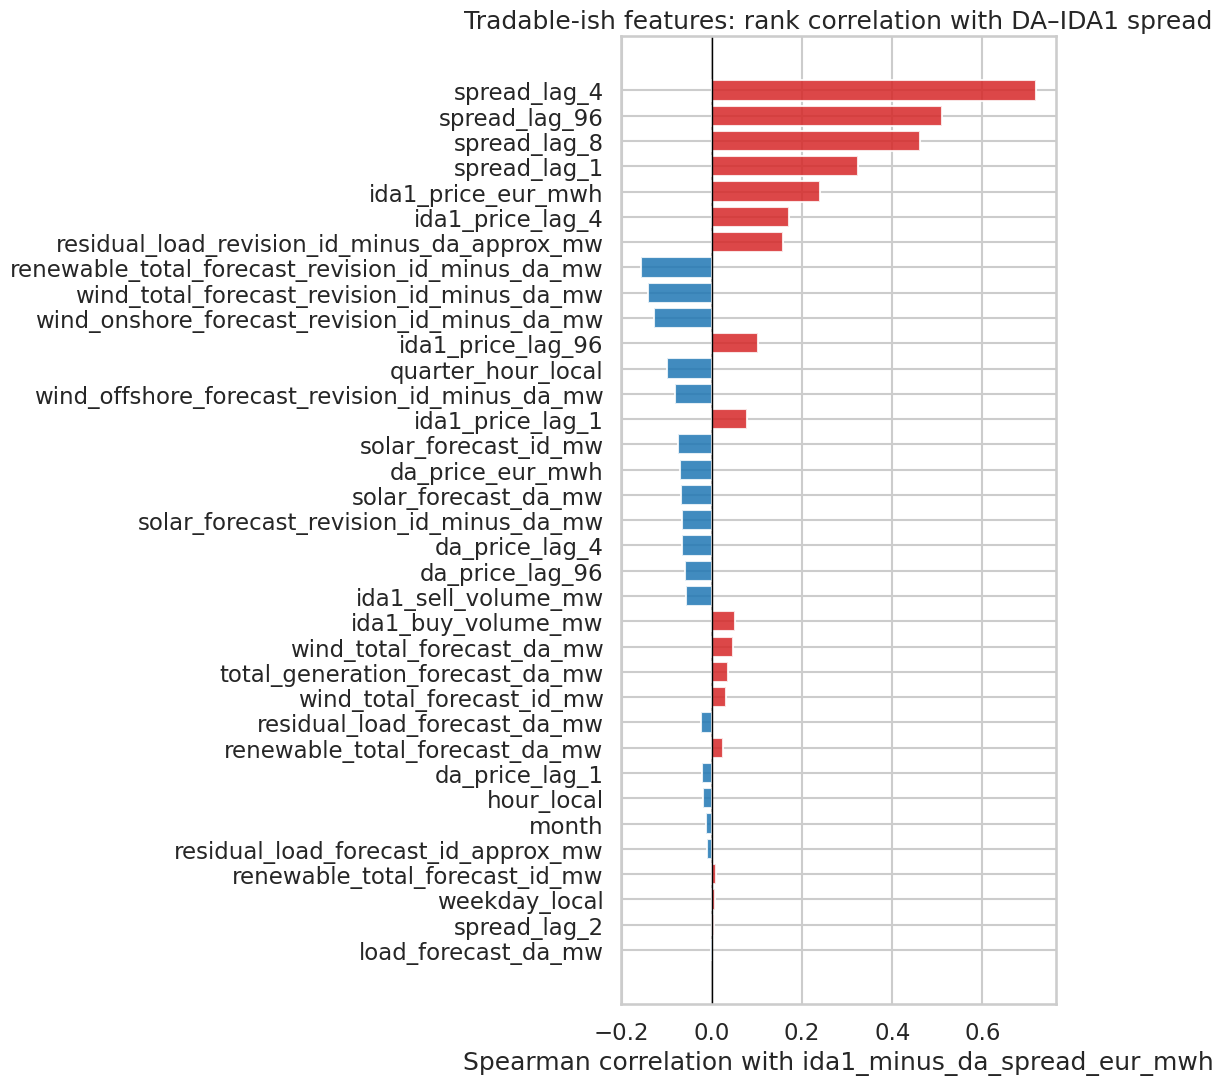

,spearman_corr
spread_lag_4,0.719231
spread_lag_96,0.510990
spread_lag_8,0.461442
spread_lag_1,0.322907
ida1_price_eur_mwh,0.239711
ida1_price_lag_4,0.171433
residual_load_revision_id_minus_da_approx_mw,0.157906
renewable_total_forecast_revision_id_minus_da_mw,-0.157899
wind_total_forecast_revision_id_minus_da_mw,-0.142095
wind_onshore_forecast_revision_id_minus_da_mw,-0.128749


In [16]:
corr_tradable_spearman = plot_corr_bar(
    analysis_df,
    TARGET,
    tradableish_features,
    title="Tradable-ish features: rank correlation with DA–IDA1 spread",
    method="spearman",
    top_n=35,
)

display(corr_tradable_spearman.to_frame("spearman_corr").head(20))

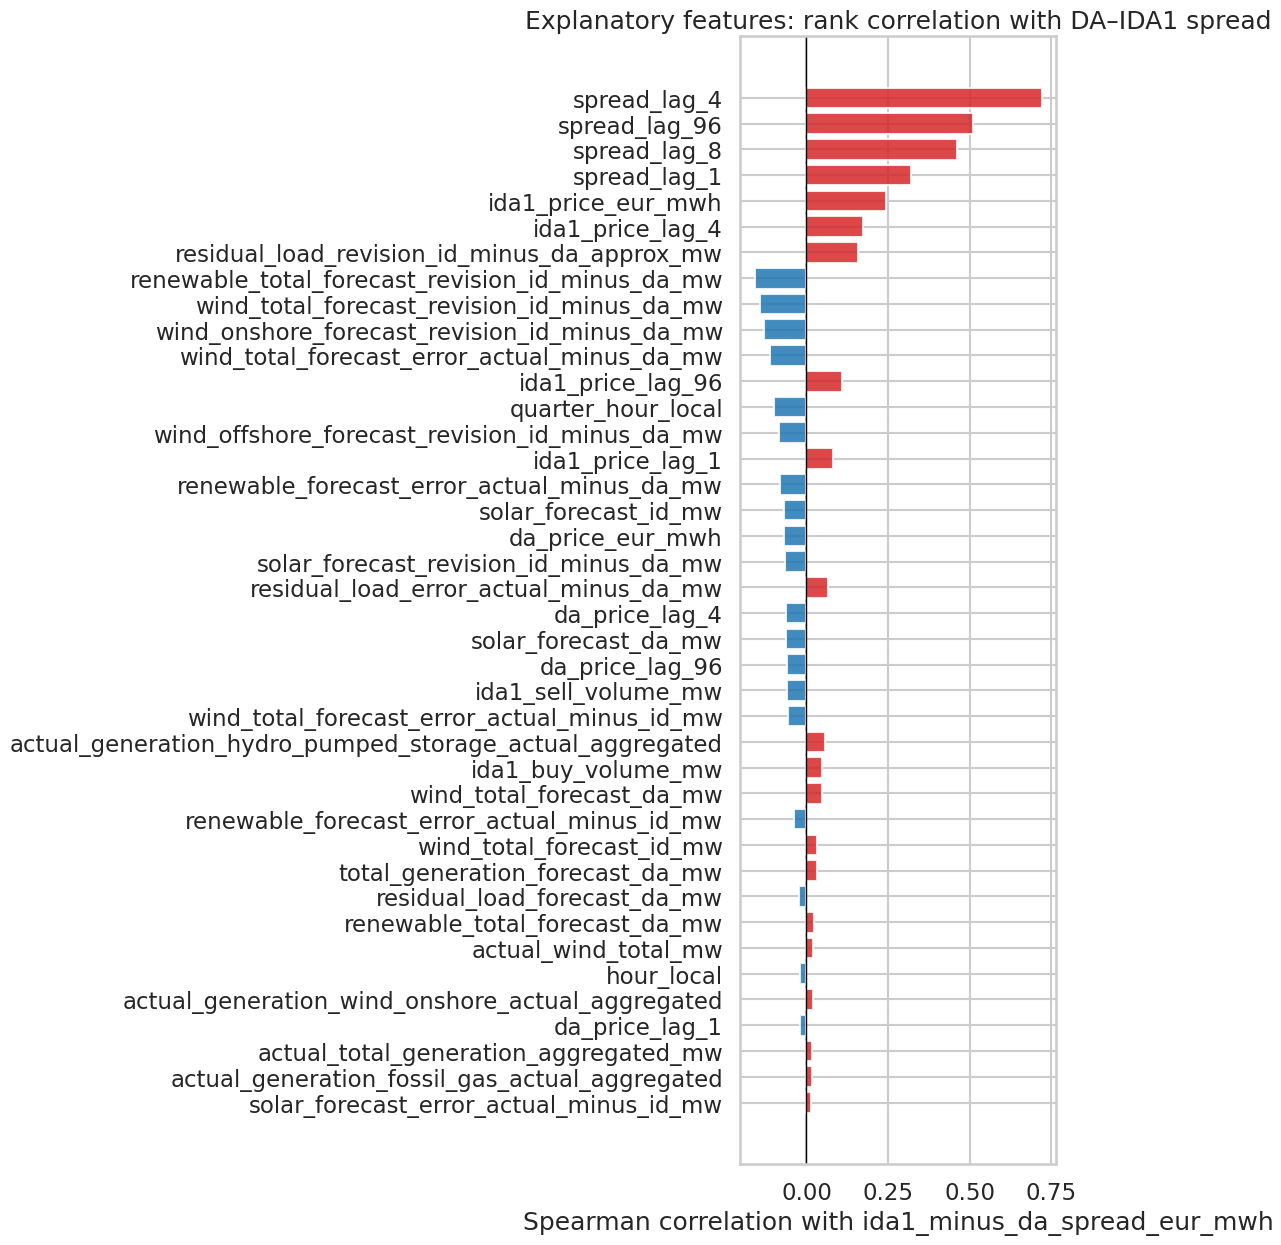

,spearman_corr
spread_lag_4,0.720265
spread_lag_96,0.509686
spread_lag_8,0.462141
spread_lag_1,0.321675
ida1_price_eur_mwh,0.243452
ida1_price_lag_4,0.174383
residual_load_revision_id_minus_da_approx_mw,0.158499
renewable_total_forecast_revision_id_minus_da_mw,-0.158492
wind_total_forecast_revision_id_minus_da_mw,-0.143328
wind_onshore_forecast_revision_id_minus_da_mw,-0.129707


In [11]:
corr_expl_spearman = plot_corr_bar(
    analysis_df,
    TARGET,
    explanatory_features,
    title="Explanatory features: rank correlation with DA–IDA1 spread",
    method="spearman",
    top_n=40,
)

display(corr_expl_spearman.to_frame("spearman_corr").head(25))

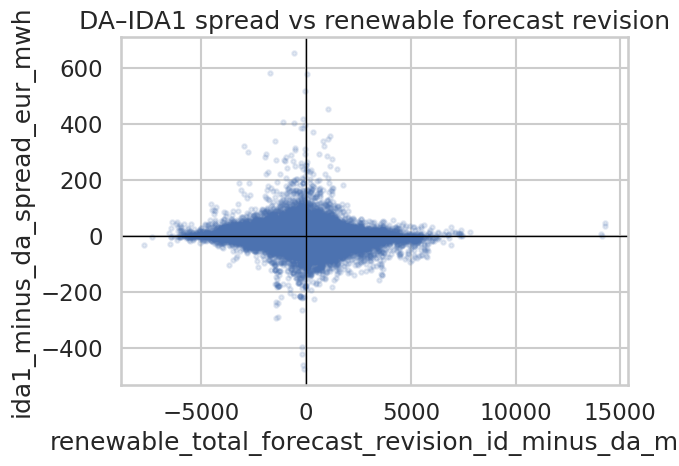

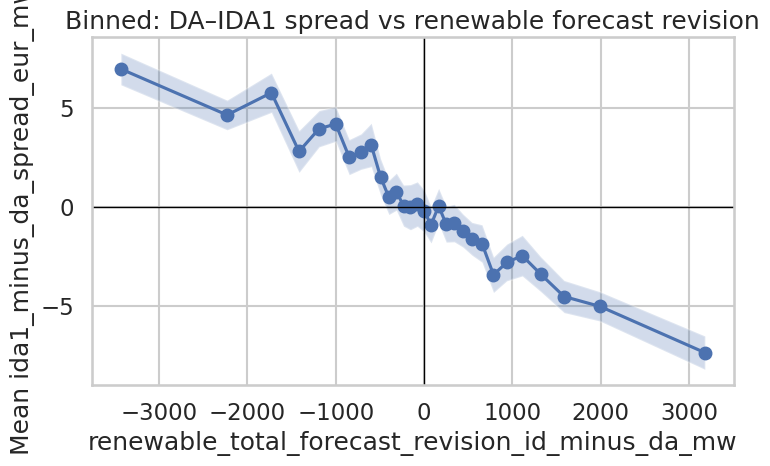

,x_mean,y_mean,y_std,n,sem
0,-3433.248375,6.975463,21.418630,2752,0.408289
1,-2230.783926,4.651327,20.064039,2752,0.382467
2,-1728.966040,5.774697,26.575454,2752,0.506590
3,-1415.900443,2.809089,28.311025,2751,0.539772
4,-1188.416666,3.958341,24.565980,2752,0.468285


In [17]:
plot_scatter(
    analysis_df,
    x="renewable_total_forecast_revision_id_minus_da_mw",
    y=TARGET,
    title="DA–IDA1 spread vs renewable forecast revision",
    alpha=0.15,
)

binned_renewable_revision = plot_binned_relationship(
    analysis_df,
    x="renewable_total_forecast_revision_id_minus_da_mw",
    y=TARGET,
    bins=30,
    title="Binned: DA–IDA1 spread vs renewable forecast revision",
)

display(binned_renewable_revision.head())

Intrahour rows before full-hour filter: 82556
Intrahour rows after full-hour filter: 81684


,quarter_hour_local,mean,std,count,sem
0,0.0,2.212519,24.465315,20421,0.171203
1,1.0,-0.207534,8.246659,20421,0.057708
2,2.0,-0.393135,8.908663,20421,0.062341
3,3.0,-1.611851,23.294123,20421,0.163008


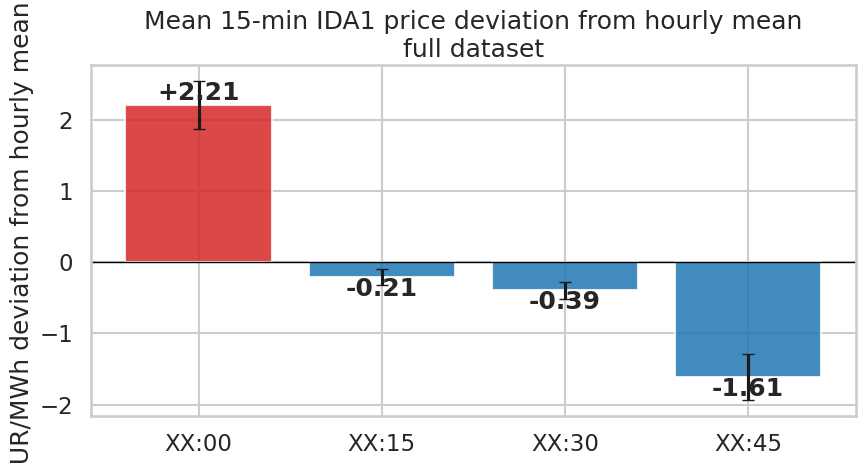

In [19]:
intrahour = df.dropna(subset=["ida1_price_eur_mwh"]).copy()

intrahour["local_hour_block"] = intrahour["timestamp_local"].dt.strftime("%Y-%m-%d %H:00")

intrahour["ida1_hourly_mean_from_qh"] = (
    intrahour.groupby("local_hour_block")["ida1_price_eur_mwh"].transform("mean")
)

intrahour["ida1_qh_deviation_from_hour_mean"] = (
    intrahour["ida1_price_eur_mwh"] - intrahour["ida1_hourly_mean_from_qh"]
)

counts_per_hour = intrahour.groupby("local_hour_block")["ida1_price_eur_mwh"].transform("count")
intrahour_full = intrahour[counts_per_hour == 4].copy()

print("Intrahour rows before full-hour filter:", len(intrahour))
print("Intrahour rows after full-hour filter:", len(intrahour_full))

qh_stats = (
    intrahour_full
    .groupby("quarter_hour_local")["ida1_qh_deviation_from_hour_mean"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

qh_stats["sem"] = qh_stats["std"] / np.sqrt(qh_stats["count"])

display(qh_stats)

plt.figure(figsize=(9, 5))
x = np.arange(len(qh_stats))
colors = np.where(qh_stats["mean"].values >= 0, "tab:red", "tab:blue")

plt.bar(
    x,
    qh_stats["mean"],
    yerr=1.96 * qh_stats["sem"],
    capsize=4,
    color=colors,
    alpha=0.85,
)

plt.axhline(0, color="black", linewidth=1)
plt.xticks(x, ["XX:00", "XX:15", "XX:30", "XX:45"])
plt.ylabel("EUR/MWh deviation from hourly mean")
plt.title("Mean 15-min IDA1 price deviation from hourly mean\nfull dataset")

for i, val in enumerate(qh_stats["mean"].values):
    plt.text(
        i,
        val,
        f"{val:+.2f}",
        ha="center",
        va="bottom" if val >= 0 else "top",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

quarter_hour_local,0.0,1.0,2.0,3.0
hour_local,,,,
0.0,12.758453,4.556776,-4.728303,-12.586926
1.0,9.909744,1.745225,-3.037811,-8.617158
2.0,4.938458,-0.664175,-1.171568,-3.102715
3.0,0.398445,-0.671404,-0.184329,0.457289
4.0,-6.129187,-2.659112,2.448561,6.339737
5.0,-10.521087,-6.180381,3.148494,13.552973
6.0,-22.726882,-4.113480,7.668521,19.171842
7.0,-9.298562,-0.372606,3.859031,5.812137
8.0,14.770884,3.793175,-3.404705,-15.159354


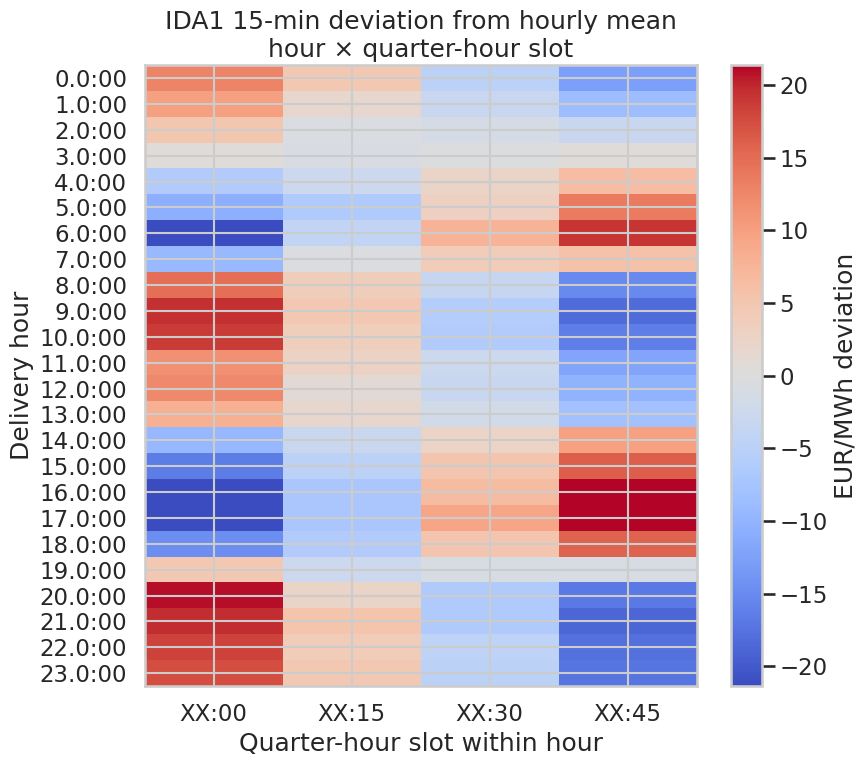

In [22]:
heat = (
    intrahour_full
    .pivot_table(
        index="hour_local",
        columns="quarter_hour_local",
        values="ida1_qh_deviation_from_hour_mean",
        aggfunc="mean",
    )
    .sort_index()
)

display(heat)

plt.figure(figsize=(9, 8))
vmax = np.nanpercentile(np.abs(heat.values), 95)

im = plt.imshow(
    heat.values,
    cmap="coolwarm",
    aspect="auto",
    vmin=-vmax,
    vmax=vmax,
)

plt.colorbar(im, label="EUR/MWh deviation")
plt.yticks(np.arange(len(heat.index)), [f"{h:02}:00" for h in heat.index])
plt.xticks(np.arange(4), ["XX:00", "XX:15", "XX:30", "XX:45"])
plt.xlabel("Quarter-hour slot within hour")
plt.ylabel("Delivery hour")
plt.title("IDA1 15-min deviation from hourly mean\nhour × quarter-hour slot")
plt.tight_layout()
plt.show()

quarter_hour_local,0.0,1.0,2.0,3.0
year,,,,
2021.0,1.864770,0.218550,0.002805,-2.086125
2024.0,3.725270,-1.236978,-1.083120,-1.405172
2025.0,2.331156,-0.347824,-0.657502,-1.325831
2026.0,1.176005,-0.150387,-0.240750,-0.784868


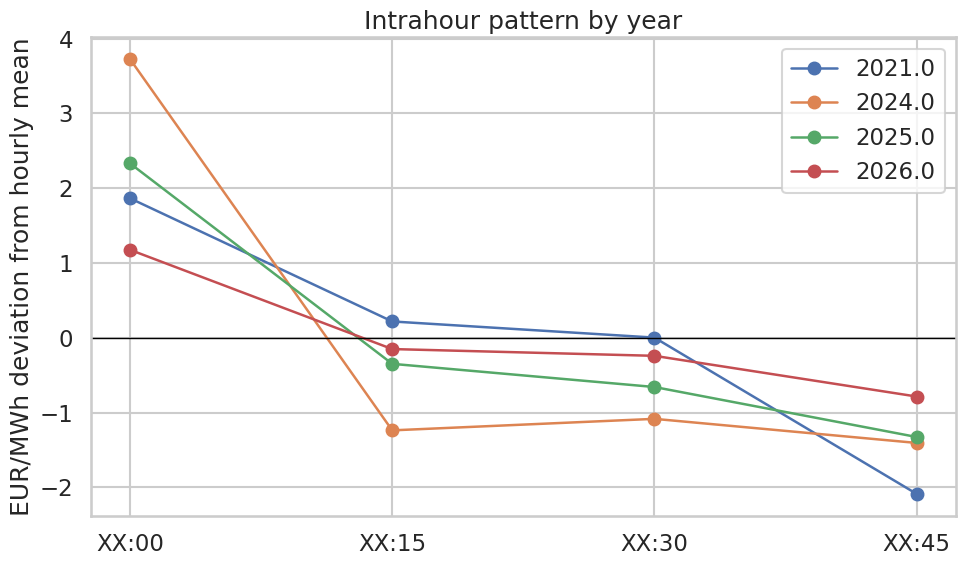

In [21]:
year_qh = (
    intrahour_full
    .groupby(["year", "quarter_hour_local"])["ida1_qh_deviation_from_hour_mean"]
    .mean()
    .unstack("quarter_hour_local")
)

display(year_qh)

plt.figure(figsize=(10, 6))

for year in year_qh.index:
    plt.plot(
        [0, 1, 2, 3],
        year_qh.loc[year].values,
        marker="o",
        linewidth=1.8,
        label=str(year),
    )

plt.axhline(0, color="black", linewidth=1)
plt.xticks([0, 1, 2, 3], ["XX:00", "XX:15", "XX:30", "XX:45"])
plt.ylabel("EUR/MWh deviation from hourly mean")
plt.title("Intrahour pattern by year")
plt.legend()
plt.tight_layout()
plt.show()